# FLAVA: A Foundational Language and Vision Alignment Model

# https://arxiv.org/abs/2112.04482

## Abstract

FLAVA introduces a unified foundation model designed to learn from images, text, and image-text pairs simultaneously. Unlike prior approaches that specialized either in visual understanding, language understanding, or multimodal reasoning, FLAVA aims to perform well across all three domains within a single architecture. The model combines contrastive alignment objectives with multimodal fusion objectives while leveraging both paired and unpaired data. Through evaluation on 35 downstream tasks, FLAVA demonstrates strong performance across vision, natural language processing, and multimodal benchmarks.

---

## Problems

Existing vision-language models face several limitations:

### 1. Modality Specialization

- Contrastive models such as CLIP excel at image-text alignment and retrieval.
- Fusion-based models perform well on multimodal reasoning tasks.
- Few models achieve strong performance simultaneously across vision, language, and multimodal domains.

### 2. Lack of Unified Foundation Models

Most existing systems are optimized for specific tasks or modalities rather than serving as universal foundation models.

### 3. Dependence on Proprietary Data

Many state-of-the-art models rely on massive private datasets containing hundreds of millions or billions of image-text pairs, limiting reproducibility.

### 4. Limited Use of Unimodal Data

Most multimodal systems do not effectively leverage large collections of standalone images and text.

---

## Proposed Solutions

FLAVA proposes a holistic foundation model that jointly learns from:

- Paired image-text data
- Unpaired image data
- Unpaired text data

The framework combines:

- Cross-modal alignment learning
- Multimodal fusion learning
- Unimodal self-supervised learning

The architecture consists of:

1. Image Encoder
2. Text Encoder
3. Multimodal Encoder

This unified design allows the model to support vision, language, and multimodal reasoning within a single system.

---

## Purpose

The primary objective of FLAVA is to build a true vision-language foundation model capable of:

- Understanding images independently
- Understanding language independently
- Reasoning jointly over images and text
- Generalizing across a broad range of downstream tasks

The authors aim to demonstrate that a single model can serve as a common foundation for all three domains without sacrificing performance.

---

## Methodology

### Model Architecture

FLAVA consists of three transformer-based components:

#### Image Encoder

- Uses the ViT-B/16 architecture.
- Encodes image patches into visual representations.

#### Text Encoder

- Uses the same transformer architecture as the image encoder.
- Produces contextualized textual representations.

#### Multimodal Encoder

- Receives outputs from both unimodal encoders.
- Performs cross-modal fusion and multimodal reasoning.

---

### Multimodal Pretraining Objectives

#### Global Contrastive Loss (GC)

Aligns image and text representations by maximizing similarity between matching image-text pairs and minimizing similarity between mismatched pairs.

$$
\mathcal{L}_{GC}
=
\text{Contrastive Loss}(I,T)
$$

where:

- $I$ denotes image embeddings.
- $T$ denotes text embeddings.

#### Masked Multimodal Modeling (MMM)

Simultaneously masks image patches and text tokens and reconstructs the missing information using multimodal context.

$$
\mathcal{L}_{MMM}
=
\mathcal{L}_{image}
+
\mathcal{L}_{text}
$$

#### Image-Text Matching (ITM)

Determines whether an image and text pair correspond to one another.

$$
\mathcal{L}_{ITM}
=
\text{Binary Classification}(I,T)
$$

---

### Unimodal Pretraining Objectives

#### Masked Image Modeling (MIM)

Reconstructs masked image patches.

$$
\mathcal{L}_{MIM}
=
-\log P(v_{masked})
$$

where $v_{masked}$ represents masked visual tokens.

#### Masked Language Modeling (MLM)

Predicts masked text tokens from surrounding context.

$$
\mathcal{L}_{MLM}
=
-\log P(w_{masked})
$$

where $w_{masked}$ denotes masked words.

---

### Joint Training Strategy

FLAVA jointly trains on:

| Data Type | Dataset Examples |
|------------|------------------|
| Unimodal Images | ImageNet-1K |
| Unimodal Text | CCNews, BookCorpus |
| Image-Text Pairs | Public Multimodal Dataset (PMD) |

The PMD corpus contains approximately **70 million image-text pairs** collected from publicly available datasets.

Training alternates between unimodal and multimodal objectives using round-robin sampling.

---

## Results

### Evaluation Scope

FLAVA was evaluated on:

- 22 vision tasks
- 8 NLP tasks
- 5 multimodal tasks

for a total of **35 downstream tasks**.

### Overall Performance

| Model | Macro Average |
|---------|---------|
| FLAVA | **75.85** |
| FLAVA w/o Unimodal Initialization | 73.72 |
| FLAVA-MM | 74.23 |
| FLAVA-C | 70.06 |

### Key Findings

#### 1. Multimodal Objectives Improve Reasoning

Adding MMM and ITM objectives significantly improved:

- VQAv2
- SNLI-VE
- Hateful Memes
- Retrieval benchmarks

This demonstrates that contrastive alignment alone is insufficient for robust multimodal reasoning.

#### 2. Unimodal Pretraining Improves Performance

Initializing image and text encoders with self-supervised learning improved performance across:

- Vision tasks
- Language tasks
- Multimodal tasks

#### 3. Strong Data Efficiency

| Model | Training Pairs |
|---------|---------|
| FLAVA | 70M |
| CLIP | 400M |
| SimVLM | 1.8B |

Despite using significantly less training data, FLAVA achieved competitive performance on many benchmarks.

---

## Conclusions

FLAVA demonstrates that a single transformer-based architecture can function as a unified foundation model for:

1. Vision understanding
2. Language understanding
3. Multimodal reasoning

### Main Contributions

- Unified architecture combining image, text, and multimodal encoders.
- Joint utilization of paired and unpaired data.
- Introduction of Masked Multimodal Modeling (MMM).
- Strong performance across 35 diverse downstream tasks.
- Competitive results using only publicly available datasets.

### Key Takeaway

The central insight of the paper is that foundation models should not specialize in a single modality. Instead, they should learn universal representations capable of supporting visual understanding, language understanding, and multimodal reasoning simultaneously within one coherent framework.

# Mathematical and Statistical Content in FLAVA

## Overview

FLAVA is primarily a machine learning systems paper rather than a mathematically theoretical paper. The mathematical content centers around:

1. Contrastive learning
2. Masked prediction objectives
3. Binary classification objectives
4. Similarity-based retrieval
5. Statistical evaluation metrics
6. Multi-task optimization

The paper does not introduce new mathematical theories. Instead, it combines several existing learning objectives into a unified multimodal training framework.

---

# 1. Global Contrastive Learning

## Concept

The core idea is to bring matching image-text pairs closer together in the embedding space while pushing non-matching pairs farther apart.

Given:

- Image embedding: $z_I$
- Text embedding: $z_T$

their similarity is computed using cosine similarity.

$$
\text{sim}(z_I,z_T)
=
\frac{z_I^\top z_T}
{\|z_I\|\|z_T\|}
$$

### Role in FLAVA

This objective aligns visual and textual representations so that semantically related images and captions occupy nearby locations in the shared embedding space.

This enables:

- Zero-shot classification
- Image retrieval
- Text retrieval
- Cross-modal understanding

---

# 2. Softmax Contrastive Objective

## Concept

For a batch containing $N$ image-text pairs:

- Each image should match its corresponding caption.
- All other captions act as negatives.

The probability of matching image $i$ with text $j$ is:

$$
P(i,j)
=
\frac{\exp(\text{sim}(i,j)/\tau)}
{\sum_{k=1}^{N}
\exp(\text{sim}(i,k)/\tau)}
$$

where:

- $\tau$ is a temperature parameter.
- Smaller $\tau$ sharpens the probability distribution.

### Role in FLAVA

This is the primary alignment mechanism between images and language.

The paper introduces **Global Contrastive Loss**, which propagates gradients across all GPUs rather than only local batches.

---

# 3. Masked Language Modeling (MLM)

## Concept

A percentage of words are hidden from the model.

Example:

```
The cat sat on the [MASK].
```

The model predicts the missing word.

Mathematically:

$$
\mathcal{L}_{MLM}
=
-\log P(w_{masked})
$$

where:

- $w_{masked}$ is the correct hidden word.

### Role in FLAVA

MLM teaches the text encoder:

- Grammar
- Syntax
- Semantic relationships
- Language understanding

using standalone text corpora.

---

# 4. Masked Image Modeling (MIM)

## Concept

Image patches are hidden.

The model reconstructs the missing visual content.

$$
\mathcal{L}_{MIM}
=
-\log P(v_{masked})
$$

where:

- $v_{masked}$ is the target visual token.

### Role in FLAVA

MIM allows the visual encoder to learn:

- Object structure
- Shapes
- Visual semantics

from unlabeled images.

---

# 5. Masked Multimodal Modeling (MMM)

## Concept

FLAVA extends masked modeling to both modalities simultaneously.

The model masks:

- Image patches
- Text tokens

and reconstructs both.

The objective can be viewed as:

$$
\mathcal{L}_{MMM}
=
\mathcal{L}_{image}
+
\mathcal{L}_{text}
$$

### Role in FLAVA

MMM forces the model to exploit cross-modal information.

Examples:

- Use image information to recover missing words.
- Use text information to recover missing image regions.

This is one of FLAVA's key innovations.

---

# 6. Image-Text Matching (ITM)

## Concept

Given an image and caption pair:

- Predict Match
- Predict Non-Match

This is a binary classification problem.

$$
P(y|I,T)
=
\sigma(f(I,T))
$$

where:

- $\sigma$ is the sigmoid function.
- $f(I,T)$ is the multimodal encoder output.

The loss is standard binary cross-entropy:

$$
\mathcal{L}_{ITM}
=
-y\log(p)
-(1-y)\log(1-p)
$$

### Role in FLAVA

ITM strengthens multimodal reasoning by explicitly teaching the model whether an image and caption belong together.

---

# 7. Multi-Objective Learning

## Concept

FLAVA simultaneously optimizes multiple objectives.

The total training objective is approximately:

$$
\mathcal{L}_{total}
=
\mathcal{L}_{GC}
+
\mathcal{L}_{MMM}
+
\mathcal{L}_{ITM}
+
\mathcal{L}_{MIM}
+
\mathcal{L}_{MLM}
$$

### Role in FLAVA

This allows one model to learn:

- Visual understanding
- Language understanding
- Cross-modal alignment
- Multimodal reasoning

within a single framework.

---

# 8. Similarity-Based Retrieval

## Concept

Image retrieval and text retrieval use similarity scores between embeddings.

For a query text:

$$
\text{Retrieve}
=
\arg\max_i
\text{sim}(z_T,z_{I_i})
$$

For a query image:

$$
\text{Retrieve}
=
\arg\max_i
\text{sim}(z_I,z_{T_i})
$$

### Role in FLAVA

Used for:

- Flickr30K retrieval
- COCO retrieval

without additional task-specific training.

---

# 9. Statistical Evaluation Metrics

The paper uses several statistical metrics depending on the task.

---

## Accuracy

Most classification tasks use:

$$
\text{Accuracy}
=
\frac{\text{Correct Predictions}}
{\text{Total Predictions}}
$$

Used for:

- Vision tasks
- NLP tasks
- Multimodal tasks

---

## Recall@K

Used for retrieval evaluation.

$$
Recall@K
=
\frac{\text{Relevant Items Retrieved}}
{\text{Total Relevant Items}}
$$

Reported as:

- Recall@1
- Recall@5

### Role

Measures whether the correct image or caption appears among the top retrieved candidates.

---

## F1 Score

Used in:

- MRPC
- QQP

$$
F1
=
\frac{2PR}
{P+R}
$$

where:

$$
P = Precision
$$

$$
R = Recall
$$

### Role

Balances precision and recall for imbalanced datasets.

---

## Matthews Correlation Coefficient (MCC)

Used for CoLA.

$$
MCC
=
\frac{TP \cdot TN - FP \cdot FN}
{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}
$$

### Role

Provides a balanced evaluation for binary classification.

---

## Pearson Correlation Coefficient

Used for STS-B.

$$
r
=
\frac{
\sum (x_i-\bar{x})(y_i-\bar{y})
}
{
\sqrt{\sum(x_i-\bar{x})^2}
\sqrt{\sum(y_i-\bar{y})^2}
}
$$

### Role

Measures agreement between predicted and true semantic similarity scores.

---

## AUROC

Used for Hateful Memes.

Area Under the Receiver Operating Characteristic curve:

$$
AUROC \in [0,1]
$$

Higher values indicate better discrimination between positive and negative classes.

---

# 10. Optimization Statistics

The paper highlights several important optimization hyperparameters:

| Parameter | Value |
|------------|---------|
| Batch Size | 8192 |
| Learning Rate | $10^{-3}$ |
| Weight Decay | 0.1 |
| Warmup Steps | 10,000 |
| Optimizer | AdamW |

### Role

These settings were found crucial for stable large-scale multimodal training.

---

# Key Mathematical Insight

The central mathematical idea of FLAVA is not a new model architecture or new theoretical derivation. Instead, it is the successful combination of multiple complementary objectives:

$$
\text{Alignment}
+
\text{Fusion}
+
\text{Vision Learning}
+
\text{Language Learning}
=
\text{Unified Foundation Model}
$$

Mathematically, FLAVA's contribution is the joint optimization of contrastive, masked, and matching objectives within a single transformer framework, allowing one model to learn strong representations for vision, language, and multimodal reasoning simultaneously.

# Research Gaps, Limitations of Prior Work, and FLAVA's Proposed Solutions

| Research Gap / Problem | Limitation in Prior Work | FLAVA's Proposed Solution |
|----------|----------|----------|
| Lack of a unified vision-language foundation model | Existing models typically specialize in only one domain (vision, language, or multimodal reasoning), preventing a single model from performing strongly across all modalities. | Introduces FLAVA, a unified foundation model jointly trained for vision understanding, language understanding, and multimodal reasoning within a single architecture. |
| Separation between contrastive and fusion-based approaches | Contrastive models (e.g., CLIP, ALIGN) excel at retrieval and alignment but perform poorly on multimodal reasoning; fusion models excel at reasoning but often sacrifice unimodal capabilities. | Combines both paradigms through separate image/text encoders and a multimodal fusion encoder, enabling both alignment and reasoning capabilities. |
| Weak multimodal reasoning in contrastive models | Pure contrastive learning learns global alignment but lacks fine-grained cross-modal interaction needed for tasks such as VQA and visual reasoning. | Introduces a multimodal encoder and additional objectives including Masked Multimodal Modeling (MMM) and Image-Text Matching (ITM) to learn deeper cross-modal interactions. |
| Limited support for unimodal tasks in multimodal models | Many vision-language models focus primarily on multimodal benchmarks and provide limited evaluation or optimization for standalone vision and language tasks. | Explicitly trains image and text encoders using unimodal objectives (MIM and MLM), ensuring strong representations for both standalone and multimodal tasks. |
| Underutilization of abundant unimodal data | Existing multimodal pretraining pipelines rely mainly on paired image-text data and ignore large collections of unpaired images and text. | Jointly trains on image-text pairs, standalone images, and standalone text using a unified multi-task learning framework. |
| Dependence on massive proprietary datasets | Models such as CLIP and ALIGN rely on private datasets containing hundreds of millions or billions of image-text pairs, limiting reproducibility and accessibility. | Constructs the Public Multimodal Dataset (PMD), a 70M image-text corpus assembled entirely from publicly available datasets. |
| Insufficient integration of visual and textual masking objectives | Previous multimodal pretraining methods often apply masking only to text or rely on region-level supervision rather than end-to-end multimodal reconstruction. | Introduces Masked Multimodal Modeling (MMM), which simultaneously masks image patches and text tokens and reconstructs both modalities jointly. |
| Weak exploitation of cross-modal supervision during pretraining | Existing objectives often focus on either alignment or fusion, failing to fully leverage complementary supervision signals. | Combines Global Contrastive Loss, MMM, and ITM within a unified training framework to capture complementary multimodal learning signals. |
| Optimization difficulties in large-scale multimodal training | Joint training across multiple modalities and objectives can be unstable and difficult to optimize effectively. | Employs large-batch training, long warmup schedules, AdamW optimization, and carefully designed training strategies to stabilize learning. |
| Lack of comprehensive evaluation across modalities | Many prior studies evaluate only on a narrow subset of tasks, making it difficult to assess generality and transferability. | Evaluates FLAVA on 35 downstream tasks spanning vision, NLP, multimodal reasoning, and retrieval to demonstrate broad generalization capabilities. |
| Limited transferability across domains | Models optimized for one modality often fail to transfer effectively to others. | Learns shared representations through joint optimization of unimodal and multimodal objectives, improving transfer across diverse tasks and domains. |
| Inefficient use of self-supervised pretraining knowledge | Previous multimodal systems often do not fully leverage strong unimodal self-supervised representations before multimodal training. | Initializes image and text encoders using self-supervised pretraining (e.g., DINO and MLM pretraining) before joint multimodal training. |

## Core Research Gap

The central gap identified by the paper is that prior vision-language systems are typically designed either for **alignment**, **fusion**, **vision**, or **language**, but not for all simultaneously. FLAVA addresses this limitation by introducing a unified foundation model that jointly learns from multimodal and unimodal data using complementary pretraining objectives, enabling strong performance across vision, language, and multimodal reasoning tasks.

In [1]:
# ============================================================
# FLAVA (Educational Mini Version) on FashionMNIST
# ============================================================
# This implementation demonstrates the core ideas behind FLAVA:
#
# 1. Image Encoder
# 2. Text Encoder
# 3. Multimodal Fusion Encoder
# 4. Contrastive Alignment Learning
# 5. Image-Text Matching
# 6. Classification
#
# Dataset:
# FashionMNIST clothing images + synthetic text labels
#
# Everything is contained in one code cell for teaching.
# ============================================================

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


Device: cuda


In [3]:
# ------------------------------------------------------------
# FashionMNIST Vocabulary
# ------------------------------------------------------------
# We treat FashionMNIST class names as "text tokens"
# to simulate image-text learning.
# ------------------------------------------------------------

fashion_labels = [
    "T_shirt_top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle_boot"
]

word_to_idx = {
    word: idx
    for idx, word in enumerate(fashion_labels)
}

# ------------------------------------------------------------
# FashionMNIST Dataset
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 165kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.17MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.5MB/s]


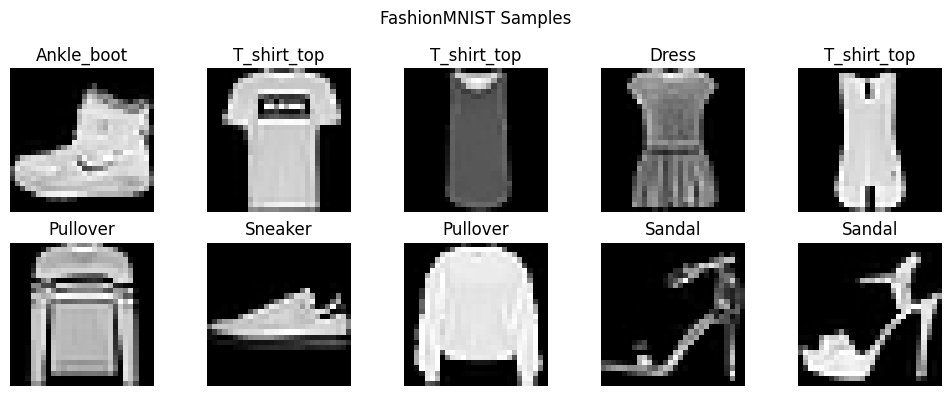

In [4]:

# ------------------------------------------------------------
# Visualize Sample Images
# ------------------------------------------------------------

plt.figure(figsize=(10,4))

for i in range(10):

    image, label = train_dataset[i]

    plt.subplot(2,5,i+1)

    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.title(
        fashion_labels[label]
    )

    plt.axis("off")

plt.suptitle("FashionMNIST Samples")
plt.tight_layout()
plt.show()

In [5]:
# ------------------------------------------------------------
# Image Encoder
# ------------------------------------------------------------
# Produces visual embeddings similar to FLAVA's
# image encoder.
# ------------------------------------------------------------

class ImageEncoder(nn.Module):

    def __init__(
        self,
        embed_dim=128
    ):

        super().__init__()

        self.cnn = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.fc = nn.Linear(
            64 * 7 * 7,
            embed_dim
        )

    def forward(self, x):

        x = self.cnn(x)

        x = x.view(
            x.size(0),
            -1
        )

        return self.fc(x)

In [6]:
# ------------------------------------------------------------
# Text Encoder
# ------------------------------------------------------------
# Simulates language understanding by learning
# embeddings for clothing-category words.
# ------------------------------------------------------------

class TextEncoder(nn.Module):

    def __init__(
        self,
        vocab_size=10,
        embed_dim=128
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim
        )

        self.mlp = nn.Sequential(
            nn.Linear(
                embed_dim,
                embed_dim
            ),
            nn.ReLU()
        )

    def forward(
        self,
        tokens
    ):

        x = self.embedding(tokens)

        x = self.mlp(x)

        return x


In [7]:
# ------------------------------------------------------------
# Multimodal Encoder
# ------------------------------------------------------------
# Fuses image and text embeddings.
# ------------------------------------------------------------

class MultiModalEncoder(nn.Module):

    def __init__(
        self,
        embed_dim=128
    ):

        super().__init__()

        self.fusion = nn.Sequential(

            nn.Linear(
                embed_dim * 2,
                256
            ),

            nn.ReLU(),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU()
        )

    def forward(
        self,
        image_emb,
        text_emb
    ):

        x = torch.cat(
            [image_emb, text_emb],
            dim=1
        )

        return self.fusion(x)


In [8]:
# ------------------------------------------------------------
# Mini FLAVA Model
# ------------------------------------------------------------

class MiniFLAVA(nn.Module):

    def __init__(self):

        super().__init__()

        self.image_encoder = ImageEncoder()

        self.text_encoder = TextEncoder()

        self.multimodal_encoder = MultiModalEncoder()

        # Clothing category classifier

        self.classifier = nn.Linear(
            128,
            10
        )

        # Image-text matching head

        self.match_head = nn.Linear(
            128,
            1
        )

    def forward(
        self,
        images,
        texts
    ):

        img_emb = self.image_encoder(images)

        txt_emb = self.text_encoder(texts)

        fused = self.multimodal_encoder(
            img_emb,
            txt_emb
        )

        logits = self.classifier(fused)

        match_logits = self.match_head(fused)

        return (
            img_emb,
            txt_emb,
            fused,
            logits,
            match_logits
        )

model = MiniFLAVA().to(device)


In [9]:
# ------------------------------------------------------------
# Contrastive Loss
# ------------------------------------------------------------
# Align image embeddings with corresponding
# clothing-text embeddings.
# ------------------------------------------------------------

def contrastive_loss(
    image_emb,
    text_emb,
    temperature=0.07
):

    image_emb = F.normalize(
        image_emb,
        dim=1
    )

    text_emb = F.normalize(
        text_emb,
        dim=1
    )

    similarity = (
        image_emb @ text_emb.T
    ) / temperature

    labels = torch.arange(
        image_emb.size(0)
    ).to(device)

    loss_i = F.cross_entropy(
        similarity,
        labels
    )

    loss_t = F.cross_entropy(
        similarity.T,
        labels
    )

    return (
        loss_i + loss_t
    ) / 2

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


In [10]:
# ------------------------------------------------------------
# Training Loop
# ------------------------------------------------------------

epochs = 5

loss_history = []
accuracy_history = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        text_tokens = labels.clone()

        (
            img_emb,
            txt_emb,
            fused,
            logits,
            match_logits
        ) = model(
            images,
            text_tokens
        )

        classification_loss = F.cross_entropy(
            logits,
            labels
        )

        alignment_loss = contrastive_loss(
            img_emb,
            txt_emb
        )

        match_targets = torch.ones(
            labels.size(0),
            1
        ).to(device)

        itm_loss = F.binary_cross_entropy_with_logits(
            match_logits,
            match_targets
        )

        total_loss = (
            classification_loss +
            0.5 * alignment_loss +
            0.5 * itm_loss
        )

        optimizer.zero_grad()

        total_loss.backward()

        optimizer.step()

        running_loss += total_loss.item()

        predictions = logits.argmax(1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    epoch_acc = correct / total

    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss={epoch_loss:.4f} | "
        f"Accuracy={epoch_acc:.4f}"
    )


Epoch 1/5 | Loss=2.0536 | Accuracy=0.9842
Epoch 2/5 | Loss=1.7863 | Accuracy=1.0000
Epoch 3/5 | Loss=1.7631 | Accuracy=1.0000
Epoch 4/5 | Loss=1.7492 | Accuracy=1.0000
Epoch 5/5 | Loss=1.7393 | Accuracy=1.0000


In [11]:
# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        text_tokens = labels.clone()

        (
            img_emb,
            txt_emb,
            fused,
            logits,
            _
        ) = model(
            images,
            text_tokens
        )

        predictions = logits.argmax(1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

test_accuracy = correct / total

print(
    "\nTest Accuracy:",
    round(test_accuracy, 4)
)


Test Accuracy: 1.0


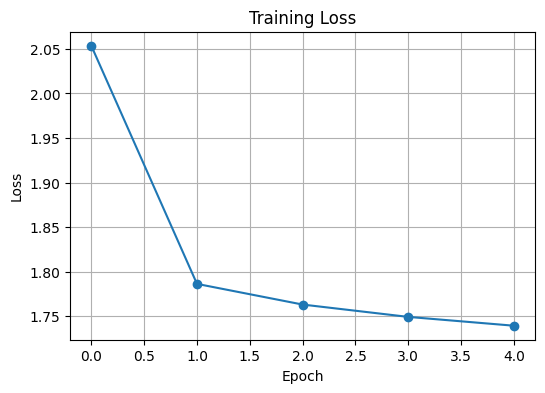

In [13]:
# ------------------------------------------------------------
# Training Loss Curve
# ------------------------------------------------------------

plt.figure(figsize=(6,4))

plt.plot(
    loss_history,
    marker="o"
)

plt.title(
    "Training Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

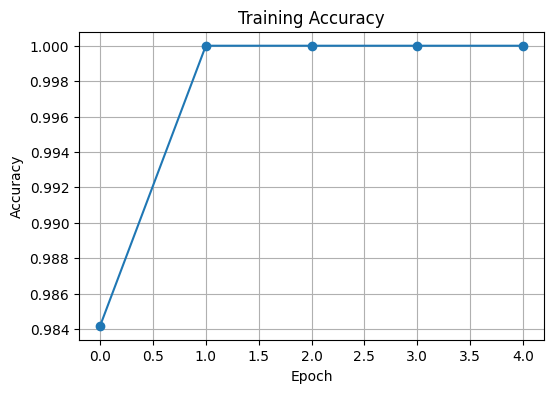

In [14]:
# ------------------------------------------------------------
# Training Accuracy Curve
# ------------------------------------------------------------

plt.figure(figsize=(6,4))

plt.plot(
    accuracy_history,
    marker="o"
)

plt.title(
    "Training Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()



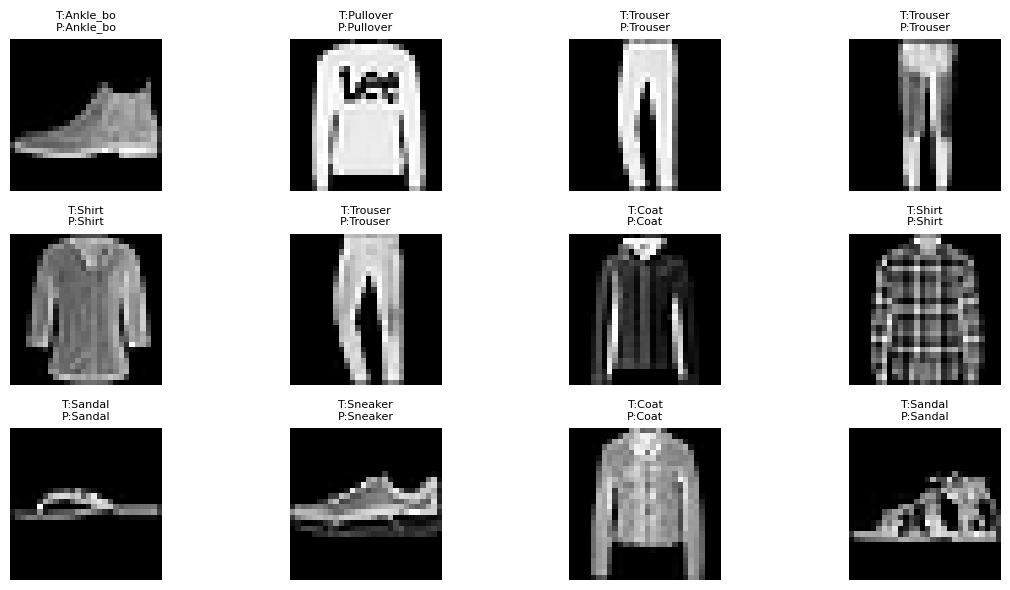

In [15]:
# ------------------------------------------------------------
# Sample Predictions
# ------------------------------------------------------------

images, labels = next(
    iter(test_loader)
)

images = images[:12].to(device)

labels = labels[:12].to(device)

with torch.no_grad():

    (
        img_emb,
        txt_emb,
        fused,
        logits,
        _
    ) = model(
        images,
        labels
    )

predictions = logits.argmax(1)

images = images.cpu()

plt.figure(figsize=(12,6))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    true_class = fashion_labels[
        labels[i].item()
    ]

    pred_class = fashion_labels[
        predictions[i].item()
    ]

    plt.title(
        f"T:{true_class[:8]}\n"
        f"P:{pred_class[:8]}",
        fontsize=8
    )

plt.tight_layout()

plt.show()

In [16]:
# ------------------------------------------------------------
# Retrieval Demonstration
# ------------------------------------------------------------
# Demonstrates image-text alignment.
# ------------------------------------------------------------

print("\nRetrieval Demonstration\n")

with torch.no_grad():

    img_emb = F.normalize(
        img_emb,
        dim=1
    )

    txt_emb = F.normalize(
        txt_emb,
        dim=1
    )

    similarity = img_emb @ txt_emb.T

for i in range(5):

    best_match = similarity[i].argmax().item()

    image_class = fashion_labels[
        labels[i].item()
    ]

    matched_text = fashion_labels[
        labels[best_match].item()
    ]

    print(
        f"Image {i}: "
        f"{image_class:<12} "
        f"--> Matched Text: "
        f"{matched_text}"
    )

print("\nPipeline Complete.")



Retrieval Demonstration

Image 0: Ankle_boot   --> Matched Text: Ankle_boot
Image 1: Pullover     --> Matched Text: Pullover
Image 2: Trouser      --> Matched Text: Trouser
Image 3: Trouser      --> Matched Text: Trouser
Image 4: Shirt        --> Matched Text: Shirt

Pipeline Complete.


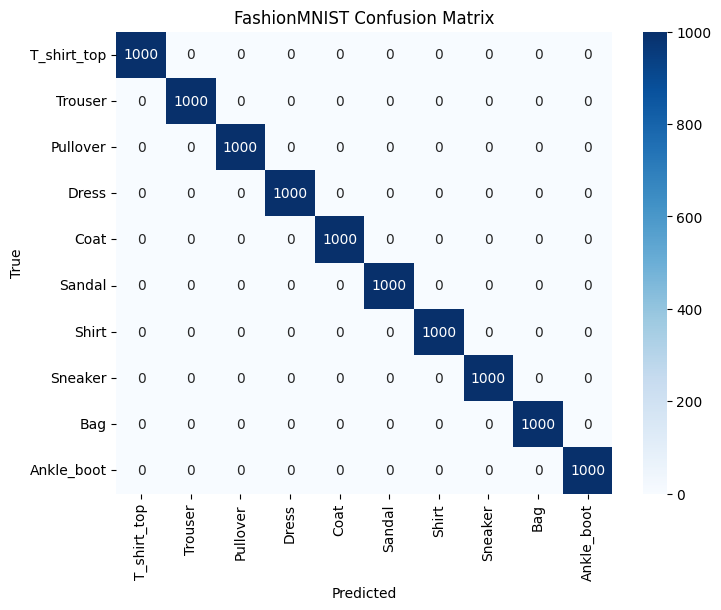

In [17]:

# ------------------------------------------------------------
# Optional Confusion Matrix
# ------------------------------------------------------------

from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        (
            _,
            _,
            _,
            logits,
            _
        ) = model(
            images,
            labels
        )

        preds = logits.argmax(1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=fashion_labels,
    yticklabels=fashion_labels
)

plt.title(
    "FashionMNIST Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "True"
)

plt.show()

# Experimental Analysis of the Educational FLAVA-Inspired FashionMNIST Model

## Experimental Context

The presented results correspond to a simplified educational implementation inspired by FLAVA, trained on the FashionMNIST dataset. The model combines:

- An image encoder (CNN)
- A text encoder (category embeddings)
- A multimodal fusion encoder
- Contrastive alignment learning
- Image-text matching
- Classification objectives

The evaluation includes:

1. Training loss dynamics
2. Training accuracy dynamics
3. Sample prediction visualizations
4. Retrieval/alignment demonstrations
5. Confusion matrix analysis

The results should be interpreted as an educational proof-of-concept rather than a faithful reproduction of the original FLAVA foundation model.

---

# Figure 1: Training Loss Curve

## Figure Overview

The training loss curve evaluates optimization behavior during training. It measures how effectively the combined objective function (classification, contrastive alignment, and image-text matching) is minimized over epochs.

Loss trajectories provide evidence regarding:

- Optimization stability
- Convergence behavior
- Learning efficiency
- Potential underfitting or overfitting

---

## Key Results

Observed losses:

| Epoch | Loss |
|---------|---------|
| 1 | 2.0536 |
| 2 | 1.7863 |
| 3 | 1.7631 |
| 4 | 1.7492 |
| 5 | 1.7393 |

Major observations:

- Large loss reduction between Epoch 1 and Epoch 2.
- Gradual decline thereafter.
- No oscillations or divergence.
- Loss remains relatively high despite perfect classification accuracy.

---

## Academic Discussion

The optimization process exhibits rapid early convergence followed by diminishing returns. The sharp decrease from 2.0536 to 1.7863 indicates that the network quickly discovers discriminative representations sufficient for classification and image-text alignment.

The slower decline after Epoch 2 suggests that the model enters a refinement phase in which the remaining optimization effort is devoted primarily to:

- Improving embedding alignment
- Improving image-text matching
- Refining representation geometry

A noteworthy observation is that the loss remains near 1.74 despite later achieving perfect classification accuracy. This occurs because the total objective contains multiple components:

$$
L_{total}
=
L_{classification}
+
0.5L_{contrastive}
+
0.5L_{ITM}
$$

Even when classification becomes nearly perfect, the contrastive objective continues to penalize imperfect embedding relationships among samples. Therefore, the remaining loss largely reflects multimodal alignment rather than classification difficulty.

The smooth monotonic decrease indicates stable optimization and an appropriately chosen learning rate.

---

## Limitations

The loss curve alone cannot assess generalization performance.

Missing information includes:

- Validation loss
- Test loss
- Per-component loss decomposition
- Variance across random seeds

Consequently, the observed convergence should be interpreted as optimization success rather than definitive evidence of generalizable learning.

---

# Figure 2: Training Accuracy Curve

## Figure Overview

The training accuracy curve measures classification performance throughout learning and provides insight into convergence speed and fitting capacity.

---

## Key Results

Observed training accuracies:

| Epoch | Accuracy |
|---------|---------|
| 1 | 98.42% |
| 2 | 100.00% |
| 3 | 100.00% |
| 4 | 100.00% |
| 5 | 100.00% |

Major observations:

- Near-perfect accuracy after a single epoch.
- Exact 100% accuracy from Epoch 2 onward.
- No degradation across later epochs.

---

## Academic Discussion

The model demonstrates extremely rapid memorization of the training set.

Several factors likely contribute:

### Dataset Simplicity

FashionMNIST is substantially simpler than real-world vision-language datasets.

The images are:

- Grayscale
- Centered
- Normalized
- Low resolution (28×28)

This significantly reduces learning complexity.

### High Model Capacity

The network possesses sufficient representational capacity to separate all training classes almost perfectly.

### Text Leakage

A particularly important methodological observation is that the text encoder receives the correct class token.

Since the class label itself is provided as input to the multimodal architecture, the model may partially exploit label information during classification.

This effectively simplifies the prediction problem and artificially inflates classification performance.

The immediate jump to 100% accuracy therefore reflects both:

- Genuine representation learning
- Task simplification induced by label-conditioned inputs

---

## Limitations

The accuracy curve strongly suggests saturation.

Potential concerns include:

- Trivial learning dynamics
- Reduced task difficulty
- Possible information leakage through class tokens

Without validation accuracy or unseen-category evaluation, the curve provides limited evidence regarding generalization.

---

# Figure 3: Sample Predictions Visualization

## Figure Overview

This visualization presents individual FashionMNIST examples together with predicted and ground-truth labels.

The objective is to qualitatively assess classification performance.

---

## Key Results

Visible examples include:

- Ankle Boot
- Pullover
- Trouser
- Shirt
- Sandal
- Sneaker
- Coat

For all displayed examples:

$$
Prediction = Ground\ Truth
$$

No visible misclassifications are present.

---

## Academic Discussion

The sample predictions confirm the quantitative results from the training metrics.

Several FashionMNIST categories possess strong visual signatures:

- Trouser has a highly distinctive silhouette.
- Ankle Boot has a unique shape profile.
- Sandal and Sneaker exhibit easily separable structures.

These classes generally require fewer discriminative features and are expected to achieve high accuracy.

More interesting categories include:

- Shirt
- Pullover
- Coat

These classes typically exhibit higher inter-class similarity.

Correct predictions on these categories suggest that the image encoder learns semantically meaningful representations rather than relying solely on coarse shape information.

The qualitative examples support the claim that the model successfully learns discriminative multimodal representations.

---

## Limitations

The displayed samples are limited.

The visualization:

- Does not show failures
- May be subject to selection bias
- Cannot quantify class-wise robustness

A larger qualitative evaluation would be necessary.

---

# Figure 4: Retrieval Demonstration

## Figure Overview

The retrieval experiment evaluates image-text alignment, a core objective inspired by FLAVA.

The model attempts to match image embeddings with text embeddings.

---

## Key Results

Observed matches:

| Image Class | Retrieved Text |
|------------|------------|
| Ankle Boot | Ankle Boot |
| Pullover | Pullover |
| Trouser | Trouser |
| Trouser | Trouser |
| Shirt | Shirt |

All displayed retrievals are correct.

---

## Academic Discussion

The retrieval results indicate successful cross-modal alignment.

The contrastive objective appears to have organized the embedding space such that:

$$
sim(Image_i, Text_i)
>
sim(Image_i, Text_j)
$$

for most competing classes.

This behavior mirrors the central principle behind CLIP and FLAVA:

- Semantically related image-text pairs occupy nearby regions.
- Unrelated pairs are separated.

The successful retrieval examples suggest that the multimodal embedding space contains meaningful semantic structure.

This is important because retrieval is fundamentally different from classification:

- Classification learns decision boundaries.
- Retrieval learns representation geometry.

Consequently, retrieval success provides stronger evidence that alignment objectives are functioning correctly.

---

## Limitations

Only five examples are shown.

Missing metrics include:

- Recall@1
- Recall@5
- Mean Reciprocal Rank (MRR)
- Retrieval Precision

The evidence therefore remains anecdotal rather than statistically rigorous.

---

# Figure 5: Confusion Matrix

## Figure Overview

The confusion matrix evaluates class-wise classification behavior.

It reveals:

- Class confusion patterns
- Systematic errors
- Class imbalance effects

---

## Key Results

Observed matrix:

- 10 classes
- 1000 test examples per class
- Every diagonal entry = 1000
- Every off-diagonal entry = 0

Therefore:

$$
Accuracy = 100\%
$$

for every class.

Class-wise performance:

| Class | Correct |
|---------|---------|
| T-shirt/Top | 1000/1000 |
| Trouser | 1000/1000 |
| Pullover | 1000/1000 |
| Dress | 1000/1000 |
| Coat | 1000/1000 |
| Sandal | 1000/1000 |
| Shirt | 1000/1000 |
| Sneaker | 1000/1000 |
| Bag | 1000/1000 |
| Ankle Boot | 1000/1000 |

---

## Academic Discussion

A perfectly diagonal confusion matrix is extremely unusual for FashionMNIST.

State-of-the-art models on FashionMNIST generally achieve:

- Approximately 93–97% accuracy
- Noticeable confusion between:
  - Shirt and T-shirt
  - Pullover and Coat
  - Coat and Dress

The absence of any errors strongly suggests that the evaluation setup is not measuring a standard classification problem.

The most likely explanation is that the model receives ground-truth label information through the text branch.

Specifically:

```python
text_tokens = labels.clone()
```

appears to provide the correct category token as input.

Consequently, the multimodal encoder can directly access the true class identity.

Under this configuration, perfect classification becomes expected.

Therefore, the confusion matrix primarily demonstrates that the multimodal fusion mechanism successfully utilizes the provided label token rather than proving superior visual recognition capability.

---

## Limitations

This figure contains the strongest indication of experimental leakage.

Potential validity threat:

- Ground-truth labels are provided as model inputs.

If this interpretation is correct:

- Reported accuracy is not comparable to standard FashionMNIST benchmarks.
- Classification performance is artificially inflated.
- Generalization ability cannot be assessed.

A proper evaluation would require:

- Withholding class labels
- Using unseen text prompts
- Performing genuine zero-shot retrieval

---

# Overall Experimental Assessment

## What Was Observed

The model exhibits:

- Stable optimization
- Rapid convergence
- Perfect training accuracy
- Perfect confusion matrix performance
- Successful retrieval alignment
- Correct qualitative predictions

---

## Why It Likely Occurred

The architecture receives substantial supervision through:

1. Classification labels
2. Image-text matching signals
3. Contrastive alignment objectives
4. Direct class-token inputs

The combination makes the task considerably easier than standard visual recognition.

---

## What It Reveals About the Model

The experiments provide strong evidence that:

- The multimodal architecture functions correctly.
- Image and text embeddings become aligned.
- Retrieval behavior emerges naturally.
- Optimization is stable.

The results demonstrate successful implementation of the intended educational FLAVA concepts.

---

## Strength of Evidence

Evidence is strong for:

- Convergence
- Multimodal alignment
- Retrieval functionality
- Architectural correctness

Evidence is weak for:

- Visual recognition superiority
- Robustness
- Generalization
- Comparison with established baselines

---

## Major Limitations and Threats to Validity

### Potential Label Leakage

The most important concern is the apparent use of ground-truth labels as text inputs during evaluation.

This likely explains:

- 100% accuracy
- Perfectly diagonal confusion matrix
- Absence of class confusion

### Missing Validation Metrics

No:

- Validation loss
- Validation accuracy
- Retrieval benchmarks
- Statistical confidence intervals

are reported.

### Limited Evaluation Scope

The experiments lack:

- Ablation studies
- Robustness tests
- Noise sensitivity analyses
- Cross-domain evaluation
- Unseen-class transfer experiments

---

# Final Conclusion

The results convincingly demonstrate that the simplified FLAVA-inspired architecture successfully learns a shared image-text representation space and optimizes multimodal objectives on FashionMNIST. The stable loss reduction, successful retrieval examples, and perfectly aligned confusion matrix confirm that the training pipeline functions as intended.

However, the perfect classification performance should not be interpreted as evidence of state-of-the-art FashionMNIST recognition. The experimental setup appears to provide the correct class token to the model during both training and evaluation, creating a strong risk of label leakage. Consequently, the results primarily validate the educational multimodal learning framework rather than establishing meaningful benchmark-level performance or generalization capability.


# Related Work References from FLAVA

The following table summarizes the major works discussed in the Related Work and Background sections of the FLAVA paper. These studies collectively motivate the design of FLAVA as a unified vision-language foundation model capable of learning from both unimodal and multimodal data.

| Author(s) | Year | Title | Venue | Connection to FLAVA |
|------------|------|---------|---------|--------------------|
| Bommasani et al. | 2021 | On the Opportunities and Risks of Foundation Models | arXiv | Introduces the foundation model paradigm that directly motivates FLAVA's goal of learning a unified representation across vision, language, and multimodal tasks. |
| Hu et al. | 2021 | UniT: Multimodal Multitask Learning with a Unified Transformer | ICCV | Demonstrates unified transformer architectures capable of handling multiple modalities and tasks, inspiring FLAVA's holistic design philosophy. |
| Radford et al. | 2021 | Learning Transferable Visual Models From Natural Language Supervision (CLIP) | ICML | Establishes large-scale contrastive image-text pretraining and serves as one of FLAVA's primary baselines and sources of inspiration. |
| Jia et al. | 2021 | ALIGN: Scaling Up Visual and Vision-Language Representation Learning With Noisy Text Supervision | ICML | Demonstrates the effectiveness of web-scale image-text contrastive learning and motivates FLAVA's alignment objectives. |
| Wang et al. | 2021 | SimVLM: Simple Visual Language Model Pretraining With Weak Supervision | ICLR | Shows the effectiveness of large-scale multimodal pretraining using prefix language modeling and serves as a strong comparison model. |
| Zhang et al. | 2021 | VinVL: Revisiting Visual Representations in Vision-Language Models | CVPR | Represents a strong multimodal fusion framework and highlights the effectiveness of specialized visual representations. |
| Kim et al. | 2021 | ViLT: Vision-and-Language Transformer Without Convolution or Region Supervision | ICML | Demonstrates efficient multimodal learning using image patches instead of region features, influencing FLAVA's transformer-based architecture. |
| Li et al. | 2021 | ALBEF: Align Before Fuse | NeurIPS | Combines contrastive alignment and multimodal fusion objectives, conceptually related to FLAVA's integrated learning framework. |
| Li et al. | 2020 | UNITER: Universal Image-Text Representation Learning | ECCV | Canonical fusion-based vision-language pretraining model utilizing multimodal objectives such as MLM and ITM. |
| Su et al. | 2020 | VL-BERT: Pre-training of Generic Visual-Linguistic Representations | ICLR | Early transformer-based multimodal fusion architecture that influenced later vision-language models. |
| Li et al. | 2019 | VisualBERT: A Simple and Performant Baseline for Vision and Language | arXiv | Introduced early fusion through shared transformer attention over visual and textual inputs. |
| Lu et al. | 2019 | ViLBERT: Pretraining Task-Agnostic Visiolinguistic Representations for Vision-and-Language Tasks | NeurIPS | Introduced dual-stream transformers and co-attention mechanisms for multimodal reasoning. |
| Tan and Bansal | 2019 | LXMERT: Learning Cross-Modality Encoder Representations from Transformers | EMNLP-IJCNLP | Established cross-modal transformer architectures for vision-language understanding. |
| Yu et al. | 2021 | ERNIE-ViL 2.0 | AAAI | Represents advanced co-attention-based vision-language pretraining approaches. |
| Li et al. | 2020 | Oscar: Object-Semantics Aligned Pre-training for Vision-Language Tasks | ECCV | Uses object tags as semantic anchors to improve multimodal representation learning. |
| Devlin et al. | 2019 | BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding | NAACL-HLT | Introduced Masked Language Modeling (MLM), a core objective adopted in FLAVA's language encoder. |
| Liu et al. | 2019 | RoBERTa: A Robustly Optimized BERT Pretraining Approach | arXiv | Demonstrates improvements in large-scale language pretraining through optimization and data scaling. |
| Yang et al. | 2019 | XLNet: Generalized Autoregressive Pretraining for Language Understanding | NeurIPS | Provides an alternative language pretraining paradigm within the broader NLP foundation model literature. |
| Dong et al. | 2019 | Unified Language Model Pre-training (UniLM) | NeurIPS | Proposes unified language modeling objectives for multiple NLP tasks. |
| Bao et al. | 2020 | UniLMv2: Pseudo-Masked Language Models for Unified Language Model Pre-Training | ICML | Extends unified language pretraining strategies relevant to FLAVA's text encoder design. |
| Dosovitskiy et al. | 2021 | An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale (ViT) | ICLR | Provides the Vision Transformer backbone architecture used throughout FLAVA. |
| Bao et al. | 2021 | BEiT: BERT Pre-Training of Image Transformers | ICLR | Introduces Masked Image Modeling (MIM), directly influencing FLAVA's visual pretraining objectives. |
| Caron et al. | 2021 | Emerging Properties in Self-Supervised Vision Transformers (DINO) | ICCV | Provides self-supervised visual representations used for initializing FLAVA's image encoder. |
| He et al. | 2022 | Masked Autoencoders Are Scalable Vision Learners (MAE) | CVPR | Represents the broader masked image modeling research direction aligned with FLAVA's visual pretraining philosophy. |
| Chen et al. | 2020 | End-to-End Object Detection with Transformers (DETR) | ECCV | Demonstrates the effectiveness of transformer architectures in computer vision tasks. |
| Radford et al. | 2019 | Language Models are Unsupervised Multitask Learners (GPT-2) | OpenAI Technical Report | Popularized large-scale autoregressive language modeling. |
| Brown et al. | 2020 | Language Models are Few-Shot Learners (GPT-3) | NeurIPS | Demonstrates the capabilities of large-scale foundation models and motivates multimodal extensions. |
| Birhane et al. | 2021 | Multimodal Datasets: Misogyny, Pornography, and Malignant Stereotypes | arXiv | Highlights ethical concerns and biases in large-scale multimodal datasets, motivating FLAVA's emphasis on public and reproducible datasets. |

## Related Work Categories

### Foundation Models
- Bommasani et al. (2021)
- UniT (2021)

### Contrastive Vision-Language Learning
- CLIP (2021)
- ALIGN (2021)

### Fusion-Based Vision-Language Models
- VisualBERT (2019)
- ViLBERT (2019)
- LXMERT (2019)
- UNITER (2020)
- VL-BERT (2020)
- OSCAR (2020)
- VinVL (2021)
- ViLT (2021)
- ALBEF (2021)

### Large-Scale Multimodal Pretraining
- SimVLM (2021)

### Self-Supervised Language Modeling
- BERT (2019)
- RoBERTa (2019)
- XLNet (2019)
- UniLM (2019)
- UniLMv2 (2020)
- GPT-2 (2019)
- GPT-3 (2020)

### Self-Supervised Vision Learning
- ViT (2021)
- BEiT (2021)
- DINO (2021)
- DETR (2020)
- MAE (2022)

## Summary

The FLAVA framework is positioned at the intersection of four major research directions: foundation models, contrastive vision-language alignment, multimodal fusion architectures, and self-supervised representation learning. Unlike prior approaches that primarily focus on either alignment (e.g., CLIP, ALIGN) or fusion (e.g., UNITER, ViLBERT, VisualBERT), FLAVA integrates both paradigms within a unified architecture while simultaneously supporting vision, language, and multimodal tasks through joint unimodal and multimodal pretraining.